# Showz — Análisis de Marketing y Producto

**Objetivo:** Analizar el uso del servicio, el comportamiento de compra y la rentabilidad del marketing para optimizar la inversión publicitaria.

**Datasets (rutas en la plataforma):**
- `/datasets/visits_log_us.csv` (sesiones/visitas)
- `/datasets/orders_log_us.csv` (pedidos)
- `/datasets/costs_us.csv` (gastos de marketing)

**Preguntas guía:**
1) ¿Cómo usan el servicio? (DAU/WAU/MAU, sesiones, duración, recurrencia, retención).
2) ¿Cuándo empiezan a comprar y cuánto compran? (demora a la primera compra, #pedidos, AOV, LTV).
3) ¿Qué tan rentable fue el marketing por fuente? (gasto total, CAC, ROMI, payback).

> **Nota de atribución:** En este cuaderno atribuiremos los ingresos **por primera fuente de adquisición** (first‑touch): todo el revenue de un usuario se asigna a la fuente de su **primera visita**. Explica en conclusiones cómo podría cambiar con otros modelos (last‑click, data‑driven, etc.).


## 0. Librerías, configuración y utilidades


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")
print(pd.__version__)

# Helper: diferencia de meses entre dos timestamps (vectorizado)
def month_diff(later, earlier):
    """Devuelve (later - earlier) en meses enteros, asumiendo ambos como timestamps de inicio de mes.
    Usa Series/Index de pandas con dtype datetime64[ns]."""
    return (later.dt.year - earlier.dt.year) * 12 + (later.dt.month - earlier.dt.month)

# Helper: estilo base de gráficos
def format_ts_plot(ax, title, xlabel='Fecha', ylabel='Valor'):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    return ax


1.2.4


## 1. Carga y preparación de datos

**Pasos:**
- Cargar CSVs.
- Normalizar nombres de columnas.
- Convertir tipos (fechas, enteros, categóricos).
- Generar columnas derivadas (duración de sesión, día/semana/mes, etc.).
- Filtrar registros inválidos (duración negativa, fechas fuera de rango, duplicados evidentes).


In [2]:
# 1.1 Cargar datos
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs  = pd.read_csv('/datasets/costs_us.csv')

print('visits:', visits.shape, 'orders:', orders.shape, 'costs:', costs.shape)
visits.head(3)


visits: (359400, 5) orders: (50415, 3) costs: (2542, 3)


,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527


In [3]:

# 1.2 Normalizar nombres de columnas
visits = visits.rename(columns={
    'Uid':'uid', 'Device':'device', 'Start Ts':'start_ts', 'End Ts':'end_ts', 'Source Id':'source_id'
})
orders = orders.rename(columns={
    'Uid':'uid', 'Buy Ts':'buy_ts', 'Revenue':'revenue'
})
costs = costs.rename(columns={
    'source_id':'source_id', 'dt':'dt', 'costs':'costs'  # por claridad, mapea a sí mismos si vienen ya en minúscula
})

# 1.3 Tipos de datos
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts']   = pd.to_datetime(visits['end_ts'])
orders['buy_ts']   = pd.to_datetime(orders['buy_ts'])
costs['dt']        = pd.to_datetime(costs['dt'])

# Convierte si aplica
if not np.issubdtype(visits['source_id'].dtype, np.number):
    visits['source_id'] = pd.to_numeric(visits['source_id'], errors='coerce').astype('Int64')

visits['device'] = visits['device'].astype('category')
orders['revenue'] = pd.to_numeric(orders['revenue'], errors='coerce')

# 1.4 Derivadas de tiempo y duración de sesión
visits['session_day']   = visits['start_ts'].dt.floor('D')
visits['session_week']  = visits['start_ts'].dt.to_period('W-MON').dt.start_time
visits['session_month'] = visits['start_ts'].dt.to_period('M').dt.start_time

visits['duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds()

# 1.5 Limpieza básica
# filtra duraciones negativas o nulas
visits = visits[visits['duration_sec'] > 0].copy()

# acota al rango del proyecto (2017-01-01 a 2018-12-31) si fuera necesario
min_date, max_date = pd.Timestamp('2017-01-01'), pd.Timestamp('2018-12-31 23:59:59')
visits = visits[(visits['start_ts'] >= min_date) & (visits['start_ts'] <= max_date)].copy()
orders = orders[(orders['buy_ts']   >= min_date) & (orders['buy_ts']   <= max_date)].copy()
costs  = costs[(costs['dt']         >= min_date) & (costs['dt']         <= max_date)].copy()

# 1.6 Entidades clave de usuario
first_session = visits.sort_values('start_ts').drop_duplicates('uid', keep='first')[['uid','start_ts','source_id','device']]
first_session = first_session.rename(columns={'start_ts':'first_visit_ts','source_id':'acquisition_source','device':'first_device'})
first_session['acq_month'] = first_session['first_visit_ts'].dt.to_period('M').dt.start_time
first_session['acq_week']  = first_session['first_visit_ts'].dt.to_period('W-MON').dt.start_time

# 1.7 Derivadas en orders y costs
orders['order_day']   = orders['buy_ts'].dt.floor('D')
orders['order_week']  = orders['buy_ts'].dt.to_period('W-MON').dt.start_time
orders['order_month'] = orders['buy_ts'].dt.to_period('M').dt.start_time

costs['cost_day']   = costs['dt'].dt.floor('D')
costs['cost_week']  = costs['dt'].dt.to_period('W-MON').dt.start_time
costs['cost_month'] = costs['dt'].dt.to_period('M').dt.start_time

# 1.8 Merge base usuario
users_base = first_session[['uid','first_visit_ts','acquisition_source','first_device','acq_month','acq_week']].copy()

print('users_base:', users_base.shape)
users_base.head(3)

users_base: (207051, 6)


,uid,first_visit_ts,acquisition_source,first_device,acq_month,acq_week
308527,13890188992670018146,2017-06-01 00:01:00,5,desktop,2017-06-01,2017-05-30
245715,16706502037388497502,2017-06-01 00:02:00,3,desktop,2017-06-01,2017-05-30
11727,10329302124590727494,2017-06-01 00:09:00,1,desktop,2017-06-01,2017-05-30


## 2. Métricas de producto (uso): DAU / WAU / MAU, sesiones, duración, recurrencia, retención

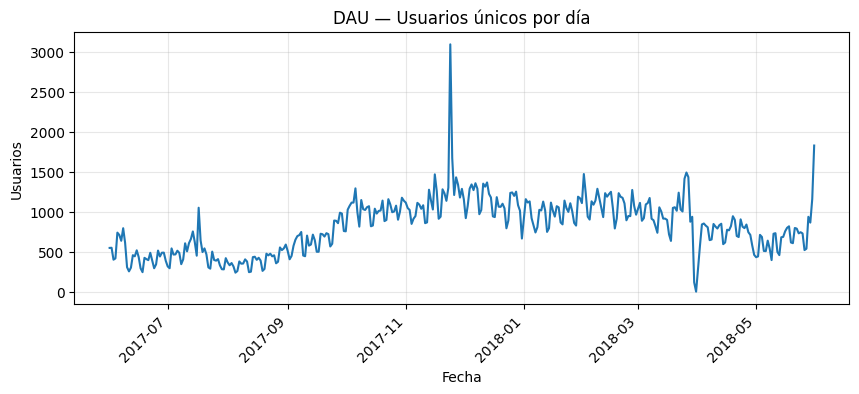

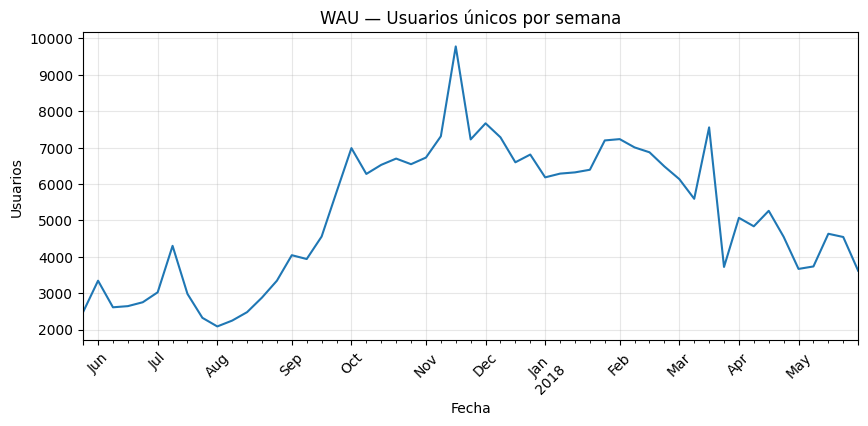

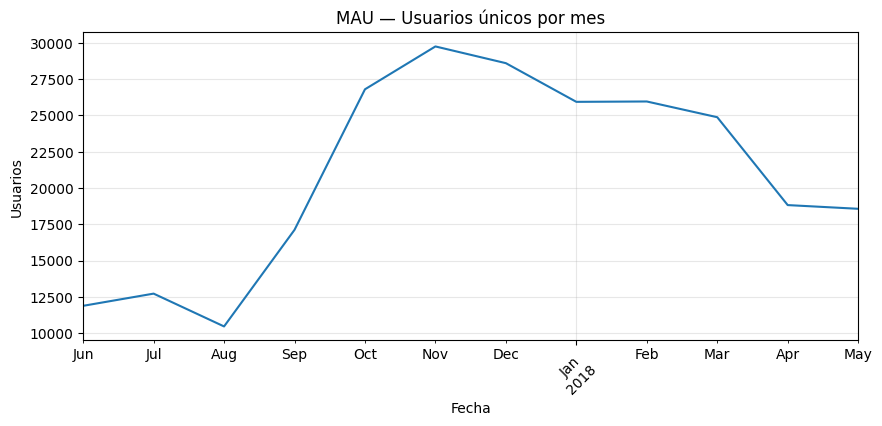

In [4]:

# 2.1 DAU/WAU/MAU
dau = visits.groupby('session_day')['uid'].nunique()
wau = visits.set_index('session_week').groupby('session_week')['uid'].nunique()
mau = visits.set_index('session_month').groupby('session_month')['uid'].nunique()

fig, ax = plt.subplots(figsize=(10,4))
dau.plot(ax=ax)
format_ts_plot(ax, 'DAU — Usuarios únicos por día', ylabel='Usuarios')
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
wau.plot(ax=ax)
format_ts_plot(ax, 'WAU — Usuarios únicos por semana', ylabel='Usuarios')
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
mau.plot(ax=ax)
format_ts_plot(ax, 'MAU — Usuarios únicos por mes', ylabel='Usuarios')
plt.show()


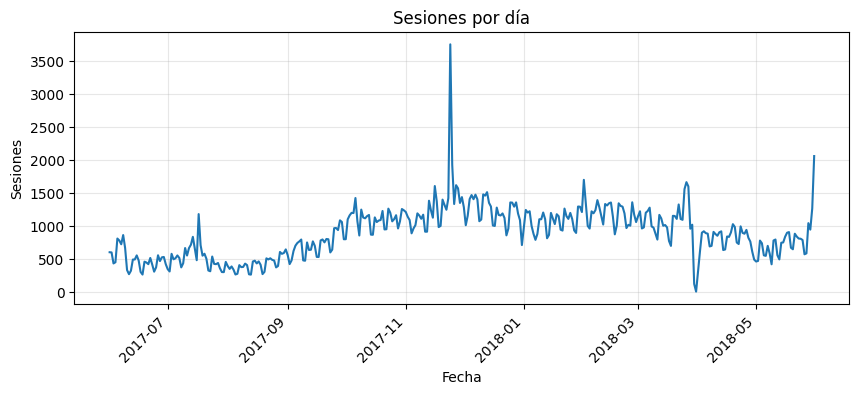

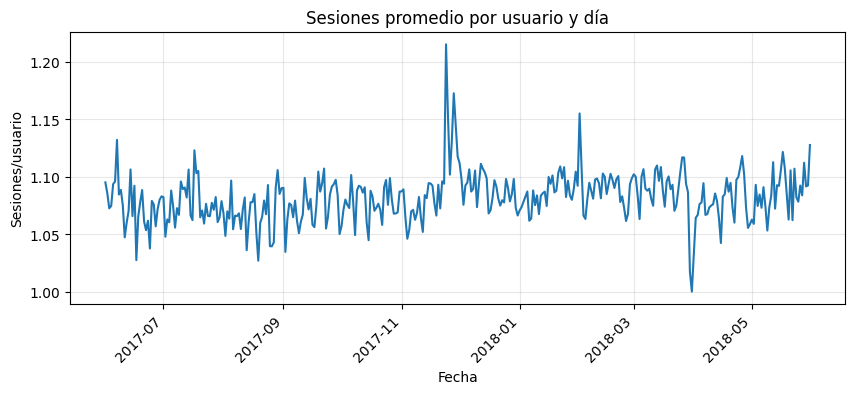

In [5]:
# 2.2 Sesiones por día y por usuario
sessions_per_day = visits.groupby('session_day').size()
fig, ax = plt.subplots(figsize=(10,4))
sessions_per_day.plot(ax=ax)
format_ts_plot(ax, 'Sesiones por día', ylabel='Sesiones')
plt.show()

sessions_per_user_day = visits.groupby(['session_day','uid']).size().groupby('session_day').mean()
fig, ax = plt.subplots(figsize=(10,4))
sessions_per_user_day.plot(ax=ax)
format_ts_plot(ax, 'Sesiones promedio por usuario y día', ylabel='Sesiones/usuario')
plt.show()

In [6]:
# 2.3 Duración de sesión
duration_stats = visits['duration_sec'].describe(percentiles=[.5,.75,.9,.95,.99]).to_frame('segundos')
duration_stats

,segundos
count,"323,604.00"
mean,714.17
std,"1,026.35"
min,19.00
50%,360.00
75%,900.00
90%,"1,680.00"
95%,"2,400.00"
99%,"4,680.00"
max,"42,660.00"


In [7]:
# 2.3 Duración de sesión
duration_stats = visits['duration_sec'].describe(percentiles=[.5,.75,.9,.95,.99]).to_frame('segundos')
duration_stats

,segundos
count,"323,604.00"
mean,714.17
std,"1,026.35"
min,19.00
50%,360.00
75%,900.00
90%,"1,680.00"
95%,"2,400.00"
99%,"4,680.00"
max,"42,660.00"


In [8]:
# 2.4 Frecuencia de retorno (gaps entre sesiones)
visits_sorted = visits.sort_values(['uid','start_ts'])
gaps_days = visits_sorted.groupby('uid')['start_ts'].diff().dt.days  # primera visita no tiene gap
gaps_days = gaps_days.dropna()

freq_return_stats = gaps_days.describe(percentiles=[.5,.75,.9,.95]).to_frame('días')
freq_return_stats

,días
count,"116,553.00"
mean,27.38
std,49.48
min,0.00
50%,4.00
75%,31.00
90%,91.00
95%,137.00
max,362.00


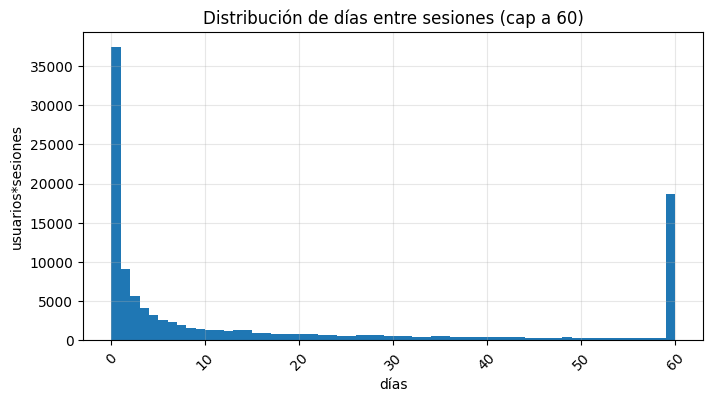

In [9]:
fig, ax = plt.subplots(figsize=(8,4))
gaps_days.clip(upper=60).plot(kind='hist', bins=60, ax=ax)  # recorte para visualizar
format_ts_plot(ax, 'Distribución de días entre sesiones (cap a 60)', xlabel='días', ylabel='usuarios*sesiones')
plt.show()

In [10]:

# 2.5 Retención por cohortes (cohorte = mes de primera visita)

# Marca cohorte y mes activo
first_visit_month = visits.groupby('uid')['session_month'].min().rename('cohort')
visits_coh = visits.merge(first_visit_month, on='uid', how='left')
visits_coh['active_month'] = visits_coh['session_month']

# Usuarios activos por (cohorte, mes activo)
retention_counts = (
    visits_coh.groupby(['cohort','active_month'])['uid']
    .nunique().reset_index(name='active_users')
)

# Tamaño de cohorte (mes 0)
cohort_sizes = retention_counts.sort_values('active_month').drop_duplicates('cohort')[['cohort','active_users']]
cohort_sizes = cohort_sizes.rename(columns={'active_users':'cohort_size'})

# Une tamaños y calcula ratio
retention = retention_counts.merge(cohort_sizes, on='cohort', how='left')
retention['period'] = month_diff(retention['active_month'], retention['cohort']).astype(int)
retention['retention_rate'] = retention['active_users'] / retention['cohort_size']

# Tabla de calor
retention_pivot = retention.pivot_table(index='cohort', columns='period', values='retention_rate', fill_value=0)
retention_pivot.round(3)

period,0,1,2,3,4,5,6,7,8,9,10,11
cohort,,,,,,,,,,,,
2017-06-01,1,0.08,0.05,0.06,0.07,0.07,0.06,0.06,0.05,0.05,0.04,0.04
2017-07-01,1,0.06,0.05,0.06,0.06,0.05,0.04,0.04,0.04,0.03,0.03,0.00
2017-08-01,1,0.07,0.06,0.06,0.05,0.04,0.04,0.04,0.03,0.03,0.00,0.00
2017-09-01,1,0.08,0.07,0.05,0.04,0.04,0.04,0.02,0.02,0.00,0.00,0.00
2017-10-01,1,0.08,0.05,0.04,0.03,0.03,0.02,0.02,0.00,0.00,0.00,0.00
2017-11-01,1,0.08,0.04,0.04,0.03,0.02,0.02,0.00,0.00,0.00,0.00,0.00
2017-12-01,1,0.06,0.04,0.03,0.02,0.02,0.00,0.00,0.00,0.00,0.00,0.00
2018-01-01,1,0.06,0.04,0.02,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2018-02-01,1,0.06,0.02,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


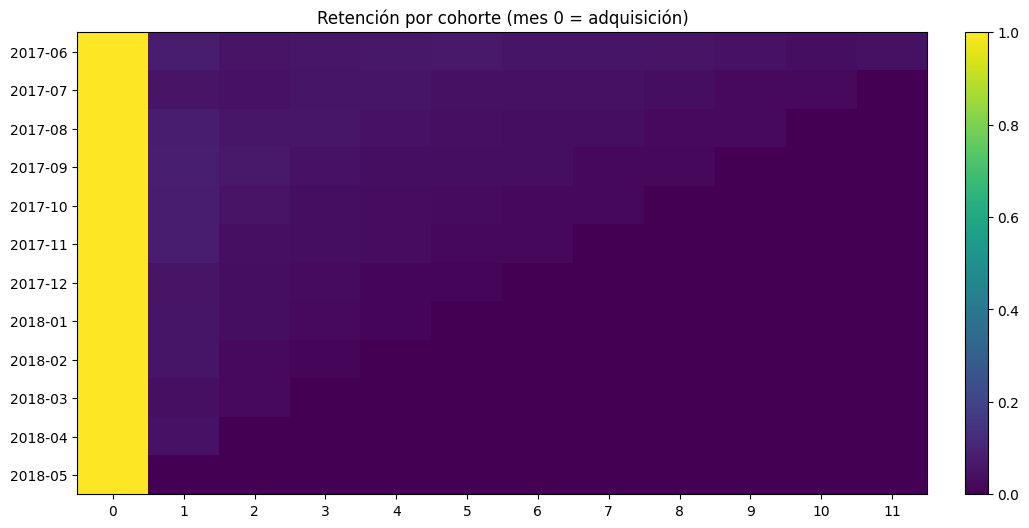

In [11]:

# Heatmap simple con matplotlib (valores impresos junto)
fig, ax = plt.subplots(figsize=(12,6))
im = ax.imshow(retention_pivot.values, aspect='auto')
ax.set_yticks(range(len(retention_pivot.index)))
ax.set_yticklabels([d.strftime('%Y-%m') for d in retention_pivot.index])
ax.set_xticks(range(len(retention_pivot.columns)))
ax.set_xticklabels(retention_pivot.columns)
ax.set_title('Retención por cohorte (mes 0 = adquisición)')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## 3. Métricas de ventas: demora a primera compra, #pedidos, AOV, LTV

In [12]:
# 3.1 Demora a primera compra desde primera visita
first_order_ts = orders.sort_values('buy_ts').drop_duplicates('uid', keep='first')[['uid','buy_ts']].rename(columns={'buy_ts':'first_order_ts'})
funnel_base = users_base.merge(first_order_ts, on='uid', how='left')
funnel_base['conversion_delay_days'] = (funnel_base['first_order_ts'] - funnel_base['first_visit_ts']).dt.days

delay_desc = funnel_base['conversion_delay_days'].describe()
delay_desc

count   36,081.00
mean        15.28
std         45.61
min       -328.00
25%          0.00
50%          0.00
75%          1.00
max        363.00
Name: conversion_delay_days, dtype: float64

In [13]:
# Buckets de conversión: 0d, 1d, 2-7d, 8-30d, 31d+
bins = [-np.inf, 0, 1, 7, 30, np.inf]
labels = ['0d', '1d', '2-7d', '8-30d', '31d+']
funnel_base['conversion_bucket'] = pd.cut(funnel_base['conversion_delay_days'], bins=bins, labels=labels)

bucket_counts = funnel_base['conversion_bucket'].value_counts(dropna=False).sort_index()
bucket_rates = (bucket_counts / len(funnel_base)).rename('share')

pd.DataFrame({'count': bucket_counts, 'share': bucket_rates})

,count,share
0d,26631,0.13
1d,948,0.00
2-7d,1967,0.01
8-30d,2025,0.01
31d+,4510,0.02
NaN,170970,0.83


In [14]:
# 3.2 Pedidos y AOV
orders_per_user = orders.groupby('uid').size().rename('orders_count')
aov = orders['revenue'].mean()
aov

4.999646930477041

In [15]:
# 3.3 LTV por cohorte (cohorte = mes de primera visita)

orders_users = orders.merge(users_base[['uid','acq_month']], on='uid', how='left')
rev_by = (orders_users.groupby(['acq_month','order_month'])['revenue'].sum().reset_index())

# Tamaños de cohorte (nuevos usuarios en acq_month)
cohort_sizes = users_base.groupby('acq_month')['uid'].nunique().rename('cohort_size').reset_index()

ltv_aux = rev_by.merge(cohort_sizes, on='acq_month', how='left')
ltv_aux['period'] = month_diff(ltv_aux['order_month'], ltv_aux['acq_month']).astype(int)

# Cumulative LTV por cohorte y periodo
ltv_aux = ltv_aux.sort_values(['acq_month','order_month'])
ltv_aux['cum_revenue'] = ltv_aux.groupby('acq_month')['revenue'].cumsum()
ltv_aux['ltv'] = ltv_aux['cum_revenue'] / ltv_aux['cohort_size']

ltv_pivot = ltv_aux.pivot_table(index='acq_month', columns='period', values='ltv', fill_value=0)
ltv_pivot.round(2)


period,-11,-9,-8,-7,-6,-5,-4,-3,-2,-1,...,2,3,4,5,6,7,8,9,10,11
acq_month,,,,,,,,,,,,,,,,,,,,,
2017-06-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.12,1.44,1.75,1.97,2.25,2.44,2.63,2.92,3.10,3.22
2017-07-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.02,1.12,1.20,1.26,1.32,1.38,1.44,1.49,1.53,0.00
2017-08-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.90,0.99,1.08,1.13,1.18,1.31,1.40,1.44,0.00,0.00
2017-09-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,1.18,1.87,1.95,2.08,2.14,2.17,2.20,0.00,0.00,0.00
2017-10-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.99,1.03,1.07,1.11,1.13,1.16,0.00,0.00,0.00,0.00
2017-11-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.83,0.89,0.93,0.96,0.98,0.00,0.00,0.00,0.00,0.00
2017-12-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.01,...,0.99,1.21,1.28,1.35,0.00,0.00,0.00,0.00,0.00,0.00
2018-01-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.66,0.68,0.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2018-02-01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.70,0.76,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


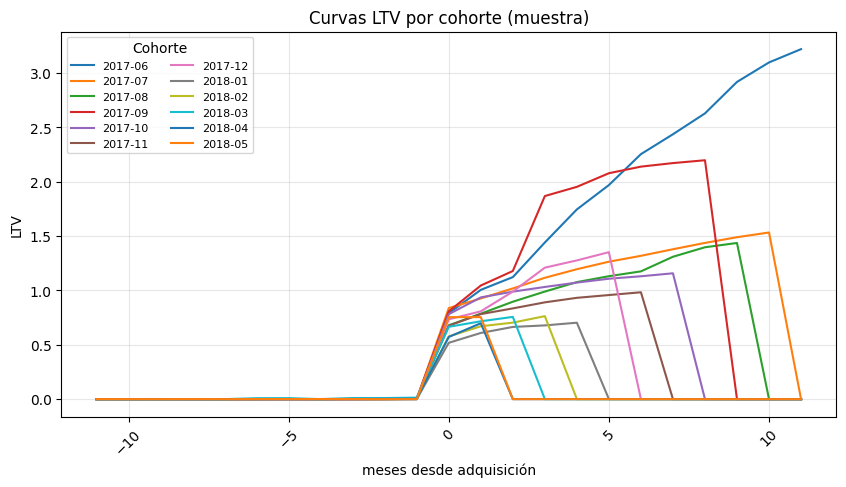

In [16]:
# Curvas LTV (algunas cohortes recientes y antiguas)
fig, ax = plt.subplots(figsize=(10,5))
sample_cohorts = ltv_pivot.index[::max(1, len(ltv_pivot)//8)]  # muestra ~8 cohortes
for coh in sample_cohorts:
    ax.plot(ltv_pivot.columns, ltv_pivot.loc[coh], label=coh.strftime('%Y-%m'))
format_ts_plot(ax, 'Curvas LTV por cohorte (muestra)', xlabel='meses desde adquisición', ylabel='LTV')
ax.legend(title='Cohorte', ncol=2, fontsize=8)
plt.show()


## 4. Métricas de marketing: gasto, CAC, ROMI y payback por fuente

In [17]:
# --- Bloque de seguridad para costs ---
# Detecta el nombre correcto de la columna de fecha en 'costs'
date_col = 'dt'
if date_col not in costs.columns:
    # a veces viene como 'date'
    if 'date' in costs.columns:
        date_col = 'date'
    else:
        raise KeyError("No encuentro la columna de fecha en costs (esperaba 'dt' o 'date').")

# Asegura tipo datetime
costs[date_col] = pd.to_datetime(costs[date_col], errors='coerce')

# Crea granularidades si faltan
if 'cost_day' not in costs.columns:
    costs['cost_day'] = costs[date_col].dt.floor('D')
if 'cost_week' not in costs.columns:
    costs['cost_week'] = costs[date_col].dt.to_period('W-MON').dt.start_time
if 'cost_month' not in costs.columns:
    costs['cost_month'] = costs[date_col].dt.to_period('M').dt.start_time


In [18]:
# 4.1 Gasto total y por fuente/mes
spend_by_source_month = costs.groupby(['source_id','cost_month'])['costs'].sum().reset_index()
spend_total = costs['costs'].sum()
spend_total, spend_by_source_month.head()

(329131.62,
    source_id cost_month    costs
 0          1 2017-06-01 1,125.61
 1          1 2017-07-01 1,072.88
 2          1 2017-08-01   951.81
 3          1 2017-09-01 1,502.01
 4          1 2017-10-01 2,315.75)

In [19]:
# 4.2 Nuevos usuarios por fuente/mes (cohorte de adquisición)
new_users_by_source_month = (
    users_base.groupby(['acquisition_source','acq_month'])['uid'].nunique()
    .rename('new_users').reset_index()
)
new_users_by_source_month = new_users_by_source_month.rename(columns={'acquisition_source':'source_id'})
new_users_by_source_month.head()

,source_id,acq_month,new_users
0,1,2017-06-01,599
1,1,2017-07-01,529
2,1,2017-08-01,355
3,1,2017-09-01,681
4,1,2017-10-01,1015


In [20]:
# 4.3 CAC por fuente/mes: CAC = gasto_mes_fuente / nuevos_usuarios_mes_fuente
# Asegura nombres consistentes para merge
cac = spend_by_source_month.merge(
    new_users_by_source_month.rename(columns={'acq_month':'cost_month', 'new_users':'new_users'}),
    on=['source_id','cost_month'],
    how='left'
)

# Renombra y calcula
cac = cac.rename(columns={'cost_month':'acq_month'})
cac['CAC'] = cac['costs'] / cac['new_users'].replace({0: np.nan})
cac.head(10)


,source_id,acq_month,costs,new_users,CAC
0,1,2017-06-01,"1,125.61",599,1.88
1,1,2017-07-01,"1,072.88",529,2.03
2,1,2017-08-01,951.81,355,2.68
3,1,2017-09-01,"1,502.01",681,2.21
4,1,2017-10-01,"2,315.75",1015,2.28
5,1,2017-11-01,"2,445.16",1120,2.18
6,1,2017-12-01,"2,341.20",1041,2.25
7,1,2018-01-01,"2,186.18",819,2.67
8,1,2018-02-01,"2,204.48",868,2.54
9,1,2018-03-01,"1,893.09",869,2.18


In [21]:
# 4.4 Ingresos atribuidos por fuente (first-touch) y ROMI por horizonte

# Atribuye cada order a la fuente y mes de adquisición del usuario
orders_attr = orders.merge(users_base[['uid','acq_month','acquisition_source']], on='uid', how='left')
orders_attr = orders_attr.rename(columns={'acquisition_source':'source_id'})

rev_by_src = (orders_attr.groupby(['source_id','acq_month','order_month'])['revenue']
              .sum().reset_index())

# Une nuevos usuarios por cohorte fuente/mes para obtener tamaños
cohort_sizes_src = new_users_by_source_month.rename(columns={'acq_month':'acq_month', 'new_users':'cohort_size'})

ltv_src = rev_by_src.merge(cohort_sizes_src, on=['source_id','acq_month'], how='left')
ltv_src['period'] = month_diff(ltv_src['order_month'], ltv_src['acq_month']).astype(int)
ltv_src = ltv_src.sort_values(['source_id','acq_month','order_month'])
ltv_src['cum_rev'] = ltv_src.groupby(['source_id','acq_month'])['revenue'].cumsum()
ltv_src['ltv_per_user'] = ltv_src['cum_rev'] / ltv_src['cohort_size']

# Une CAC para calcular ROMI por periodo
romi = ltv_src.merge(cac[['source_id','acq_month','CAC']], on=['source_id','acq_month'], how='left')
romi['ROMI'] = (romi['ltv_per_user'] - romi['CAC']) / romi['CAC']
romi.head(10)


,source_id,acq_month,order_month,revenue,cohort_size,period,cum_rev,ltv_per_user,CAC,ROMI
0,1.00,2017-06-01,2017-06-01,"1,321.24",599,0,"1,321.24",2.21,1.88,0.17
1,1.00,2017-06-01,2017-07-01,657.84,599,1,"1,979.08",3.30,1.88,0.76
2,1.00,2017-06-01,2017-08-01,656.92,599,2,"2,636.00",4.40,1.88,1.34
3,1.00,2017-06-01,2017-09-01,"1,322.09",599,3,"3,958.09",6.61,1.88,2.52
4,1.00,2017-06-01,2017-10-01,924.16,599,4,"4,882.25",8.15,1.88,3.34
5,1.00,2017-06-01,2017-11-01,516.67,599,5,"5,398.92",9.01,1.88,3.80
6,1.00,2017-06-01,2017-12-01,518.92,599,6,"5,917.84",9.88,1.88,4.26
7,1.00,2017-06-01,2018-01-01,849.19,599,7,"6,767.03",11.30,1.88,5.01
8,1.00,2017-06-01,2018-02-01,454.20,599,8,"7,221.23",12.06,1.88,5.42
9,1.00,2017-06-01,2018-03-01,358.76,599,9,"7,579.99",12.65,1.88,5.73


In [22]:
# 4.5 Payback: primer periodo donde LTV >= CAC por (fuente, cohorte)
payback = (
    romi[~romi['ltv_per_user'].isna() & ~romi['CAC'].isna()]
    .assign(payback_hit=lambda df: df['ltv_per_user'] >= df['CAC'])
)

payback_period = (
    payback[payback['payback_hit']]
    .groupby(['source_id','acq_month'])['period'].min().reset_index(name='payback_months')
)

payback_period.sort_values(['payback_months','source_id','acq_month']).head(20)


,source_id,acq_month,payback_months
0,1.00,2017-06-01,0
24,10.00,2018-03-01,0
3,1.00,2017-09-01,1
4,1.00,2017-10-01,1
13,4.00,2017-11-01,1
1,1.00,2017-07-01,2
8,2.00,2017-09-01,2
9,2.00,2017-12-01,2
14,5.00,2017-06-01,2
16,5.00,2017-08-01,2


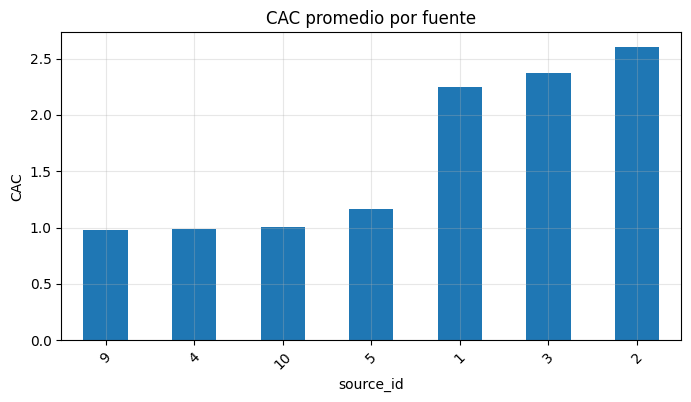

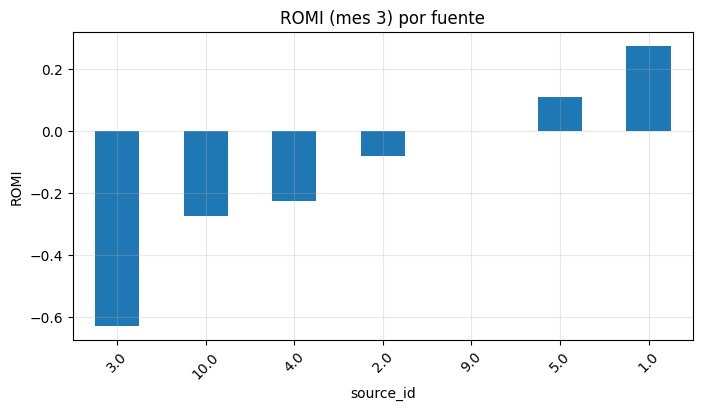

In [23]:
# 4.6 Visualizaciones de marketing
# CAC por fuente (promedio a lo largo del tiempo)
cac_avg = cac.groupby('source_id')['CAC'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8,4))
cac_avg.plot(kind='bar', ax=ax)
format_ts_plot(ax, 'CAC promedio por fuente', xlabel='source_id', ylabel='CAC')
plt.show()

# ROMI al mes 3 por fuente (si existe ese horizonte)
romi_m3 = romi[romi['period']==3].groupby('source_id')['ROMI'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8,4))
romi_m3.plot(kind='bar', ax=ax)
format_ts_plot(ax, 'ROMI (mes 3) por fuente', xlabel='source_id', ylabel='ROMI')
plt.show()


## 5. Prueba de hipótesis (opcional): duración media de sesión por fuente

Ejemplo: comparar `ad` vs `organic` si **`source_id`** o una columna categórica equivalente lo permite (ajusta la selección a tu esquema real).


In [24]:
# Ajusta los identificadores de fuente según tu dataset (ej.: 1=ad, 2=organic) si es necesario.
# Aquí mostramos una comparación genérica entre dos fuentes distintas presentes en 'source_id'.

sources = visits['source_id'].dropna().unique()
if len(sources) >= 2:
    s1, s2 = sources[:2]
    g1 = visits.loc[visits['source_id']==s1, 'duration_sec']
    g2 = visits.loc[visits['source_id']==s2, 'duration_sec']

    # Prueba t de Welch (asumiendo no igualdad de varianzas)
    from scipy import stats as st
    stat, pval = st.ttest_ind(g1, g2, equal_var=False, nan_policy='omit')

    alpha = 0.05
    print(f'Comparando source_id={s1} vs source_id={s2} — p-value={pval:.6f}')
    if pval < alpha:
        print('Rejecting the null hypothesis')
    else:
        print('Failed to reject the null hypothesis')
else:
    print('No hay suficientes fuentes distintas en "source_id" para la prueba.')


Comparando source_id=4 vs source_id=2 — p-value=0.000000
Rejecting the null hypothesis


## 6. Conclusiones y recomendaciones

**Resumen ejecutivo (bullet points):**
- Canales más eficientes por **ROMI** y **payback**: …
- Diferencias por **dispositivo** (CAC, LTV, conversión): …
- Comportamiento de usuarios (**retención**, **demora a primera compra**): …

**Recomendaciones de inversión (ejemplo):**
- Aumentar inversión en fuentes con **payback ≤ 3 meses** y ROMI consistentemente positivo.
- Reducir/pausar fuentes con **CAC alto** y **LTV plano** (sin señales de recuperación en 3–4 meses).
- Probar creatividades/landing en fuentes con CAC medio pero alta **conversión 0–7d**.
- Segmentar por **device** si se observa mejor unit economics (p. ej., móvil con mejor AOV pero menor retención).

**Aspectos metodológicos/limitaciones:**
- Atribución first‑touch (posibles sesgos frente a last‑click).
- Horizonte de observación acotado (2017–2018) — riesgo de sesgo estacional.
- Datos faltantes o registros anómalos filtrados (impacto en métricas).


---

### Apéndice A — Diccionario de columnas derivadas
- `session_day`, `session_week`, `session_month`: granularidades de tiempo de las sesiones.
- `duration_sec`: duración de la sesión en segundos.
- `first_visit_ts`: timestamp de primera visita de cada usuario.
- `acquisition_source`: fuente de adquisición (de la primera visita).
- `acq_month`, `acq_week`: mes/semana de adquisición.
- `order_day`, `order_week`, `order_month`: granularidades de tiempo de pedidos.
- `cohort_size`: tamaño de cohorte (nuevos usuarios) por mes.
- `ltv`: LTV acumulado por cohorte (revenue acumulado / cohort_size).
- `CAC`: costo de adquisición por fuente/mes (gasto / nuevos usuarios).
- `ROMI`: (LTV_per_user − CAC) / CAC por fuente y cohorte.
- `payback_months`: primer mes donde LTV_per_user ≥ CAC.